# Quantum Randomness → Music

### *Can a quantum measurement become a melody?*

**An experiment from the Schrödinger's Gambit project.**

This notebook builds a small quantum circuit, measures it on a quantum simulator, and turns the resulting measurement outcomes into a short musical composition. Qubits are placed into superposition using Hadamard gates, measured, and the classical bits that come out are used — transparently and deterministically — to choose pitches, octaves, note durations, velocities, and rests.

This is **not** a random music generator that happens to mention quantum computing. The bitstream that drives every note in the primary melody is produced by executing an actual quantum circuit on a simulator (with optional support for real quantum hardware described later). Everything after measurement — the musical mapping, the MIDI file, the audio — is a classical, inspectable algorithm applied to that quantum-generated data.

By the end of this notebook you will have:

- Built and executed a real quantum circuit.
- Extracted a classical bitstream from its measurement outcomes.
- Mapped that bitstream to musical parameters using a documented, fixed algorithm.
- Generated an audible melody and a portable MIDI file.
- Compared the quantum-driven melody against a classically-seeded one.
- Learned precisely which part of this pipeline is quantum, and which is not.

## Experiment Overview

Quantum Circuit → Measurement → Bitstream → Numerical Values → Musical Parameters → Melody → MIDI / Audio


| Stage | What happens | Quantum or classical? |
|---|---|---|
| Quantum Circuit | Qubits are placed in superposition with Hadamard gates | Quantum |
| Measurement | Each qubit is measured, collapsing it to 0 or 1 | Quantum |
| Bitstream | Many measurements are concatenated into a string of bits | Result of a quantum process |
| Numerical Values | Groups of bits are converted to integers | Classical (deterministic arithmetic) |
| Musical Parameters | Integers are mapped to pitch, octave, duration, velocity, rest | Classical (deterministic algorithm) |
| Melody | Parameters are assembled into an ordered sequence of notes | Classical |
| MIDI / Audio | The melody is rendered into a playable file | Classical |

Only the first two stages are quantum. Everything downstream is a deterministic, inspectable classical algorithm applied to the quantum-generated data. This distinction is discussed in detail in the "What Is Actually Quantum?" section near the end of the notebook.

## Scientific Background

**Qubit.** The basic unit of quantum information. Unlike a classical bit, which is definitely 0 or definitely 1, a qubit can exist in a *superposition* of both states at once.

**Superposition.** A qubit's state can be written as a linear combination of the basis states |0⟩ and |1⟩. It is not secretly 0 or 1 before measurement — both possibilities genuinely coexist in the mathematical description of the system.

**Hadamard gate (H).** A single-qubit gate that transforms |0⟩ into an equal superposition of |0⟩ and |1⟩:

H|0⟩ = (|0⟩ + |1⟩) / √2

**Measurement.** Measuring a qubit forces it to collapse to one of the two classical outcomes, 0 or 1. For the state above, quantum mechanics predicts:

P(0) = |1/√2|² = 0.5

P(1) = |1/√2|² = 0.5

So an H-gate followed by measurement produces a classical bit that is 0 or 1 with approximately equal probability, in the idealized, noise-free case.

**Classical bits.** Once measured, a qubit's outcome is an ordinary classical bit: it can be stored, copied, and processed with normal classical computation, exactly like any other 0 or 1. There is nothing quantum left in that bit after it has been recorded.

**Simulated quantum measurement.** This notebook uses `qiskit-aer`, a classical software simulator that computes the exact quantum-mechanical probabilities of a circuit and then samples from that distribution using a classical pseudorandom number generator internally. This is standard practice in quantum-software development and education, and it is explicitly distinguished from physical quantum hardware later in this notebook.

## Why Music?

A quantum measurement collapses a superposition into one of several discrete outcomes. Repeating this many times produces a stream of discrete values. Any such stream of discrete values, quantum or classical, can be interpreted through a fixed mapping into structured parameters.

Music is a convenient and honest way to make this abstract process perceivable: a sequence of numbers becomes a sequence of notes you can listen to, and every step of the transformation from qubit to sound can be inspected and explained.

To be explicit about what this experiment does and does not claim:

- It does **not** claim quantum computers are better composers than classical algorithms.
- It does **not** claim the resulting audio is itself quantum in any physical sense.
- It does **not** claim any advantage over well-implemented classical pseudorandom generators for this purpose.

What it does demonstrate is a complete, working pipeline in which the stochastic input to a creative process is genuinely sourced from quantum measurement outcomes, with every subsequent step documented and reproducible.

In [4]:
!pip install -q 'qiskit>=1.0.0' 'qiskit-aer>=0.13.0' pylatexenc midiutil
!apt-get -qq update
!apt-get -qq install -y fluidsynth fluid-soundfont-gm

print('Installation complete.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 89.0 MB/s eta 0:00:00
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Installation complete.


In [5]:
# Imports
#
# Quantum computing, numerical/data processing, visualization, music/MIDI,
# and audio are imported here in one place. The random module used only
# in the classical-comparison section later is imported separately there,
# to keep the separation between quantum and classical randomness explicit.

%matplotlib inline

try:
    from qiskit import QuantumCircuit, transpile
    from qiskit_aer import AerSimulator
except ImportError as exc:
    raise ImportError(
        'Qiskit / Qiskit Aer not found. Please run the installation cell above first.'
    ) from exc

import os
import shutil
import subprocess

import pandas as pd
import matplotlib.pyplot as plt

from midiutil import MIDIFile
from IPython.display import Audio, display

print('All imports successful.')

All imports successful.


In [6]:
# Configuration
#
# Every musical and quantum parameter used in this notebook is defined
# here. Change these values to explore different musical styles without
# touching any other cell.

# --- Quantum circuit configuration ---
NUM_QUBITS = 8                 # Qubits per circuit execution (per shot).
DISTRIBUTION_SHOTS = 2000      # Shots used only for the demonstration
                                # histogram in the Quantum Randomness
                                # section; not used to generate music.
SIMULATOR_BACKEND = 'aer_simulator'  # Name of the simulator backend used.

# --- Musical configuration ---
NUM_NOTES = 24                  # Number of notes in the generated melody.
TEMPO = 100                     # Beats per minute.
TIME_SIGNATURE = (4, 4)         # Beats per bar, beat unit (display only).

SCALE_NAME = 'major'            # Key into the SCALES dictionary (Cell 13).
ROOT_NOTE = 'C'                 # Root / tonic note name.

OCTAVE_BASE = 4                 # Lowest octave used.
OCTAVE_SPAN = 2                 # Number of usable octaves, e.g. 2 -> {4, 5}.

NOTE_DURATION_OPTIONS = [0.25, 0.5, 0.75, 1.0]  # Durations in beats.

VELOCITY_RANGE = (55, 110)      # (min, max) MIDI velocity, 0-127.

REST_THRESHOLD_VALUE = 3        # A note becomes a rest when the quantum
                                 # rest value (0-3) equals this number,
                                 # giving an approximate 25 percent rest
                                 # rate for uniformly distributed bits.

# --- Bit allocation per note ---
# Single source of truth for how many quantum bits drive each parameter.
BIT_ALLOCATION = {
    'scale_degree': 3,  # 0-7 -> scale degree, with automatic octave wrap
    'octave':       2,  # 0-3 -> octave offset
    'duration':     2,  # 0-3 -> index into NOTE_DURATION_OPTIONS
    'velocity':     3,  # 0-7 -> scaled into VELOCITY_RANGE
    'rest':         2,  # 0-3 -> rest if equal to REST_THRESHOLD_VALUE
}
BITS_PER_NOTE = sum(BIT_ALLOCATION.values())

print(f'Bits required per note: {BITS_PER_NOTE}')
print(f'Bits required for a {NUM_NOTES}-note melody: {NUM_NOTES * BITS_PER_NOTE}')

Bits required per note: 12
Bits required for a 24-note melody: 288


## Quantum Randomness

The circuit used to generate every bit in this experiment is intentionally simple:

|0⟩ → H → Measure

Applied to `NUM_QUBITS` qubits in parallel, and repeated over many independent circuit executions (shots), this produces a stream of classical bits where, ideally:

P(0) ≈ 0.5

P(1) ≈ 0.5

for each individual bit. The next few cells build this circuit, run it on the `AerSimulator`, and visualize the resulting distribution before it is ever used for music.

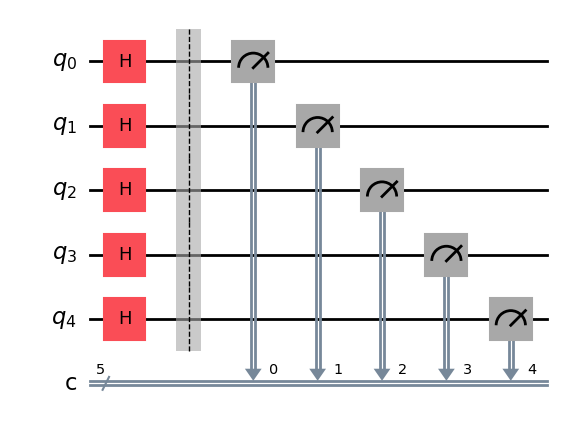

In [7]:
def build_hadamard_circuit(num_qubits: int) -> QuantumCircuit:
    '''
    Build the core quantum circuit used throughout this experiment.

    Each qubit starts in the |0> state, a Hadamard gate places it into
    an equal superposition (|0> + |1>) / sqrt(2), and then it is measured
    into a classical bit.

    Parameters
    ----------
    num_qubits : int
        Number of qubits (and classical bits) in the circuit.

    Returns
    -------
    QuantumCircuit
        A circuit with an H gate on every qubit, followed by measurement.
    '''
    if num_qubits < 1:
        raise ValueError('num_qubits must be a positive integer.')
    circuit = QuantumCircuit(num_qubits, num_qubits, name='hadamard_randomness')
    circuit.h(range(num_qubits))
    circuit.barrier()
    circuit.measure(range(num_qubits), range(num_qubits))
    return circuit


# A small circuit is used here purely so the diagram stays readable.
demo_circuit = build_hadamard_circuit(min(NUM_QUBITS, 5))
demo_circuit.draw('mpl')

In [8]:
try:
    simulator = AerSimulator()
except Exception as exc:
    raise RuntimeError(
        'Could not initialize the Qiskit Aer simulator. Make sure '
        'qiskit-aer is installed (see the installation cell).'
    ) from exc

demo_job = simulator.run(transpile(demo_circuit, simulator), shots=DISTRIBUTION_SHOTS)
demo_result = demo_job.result()
counts = demo_result.get_counts()

print(f'Executed a {demo_circuit.num_qubits}-qubit circuit with {DISTRIBUTION_SHOTS} shots.')
print(f'Distinct bitstrings observed: {len(counts)} out of {2 ** demo_circuit.num_qubits} possible.')
print()
print('Sample of measurement counts:')
for bitstring, count in list(counts.items())[:8]:
    probability = count / DISTRIBUTION_SHOTS
    print(f'  {bitstring} : {count:5d} shots  (p ~ {probability:.3f})')

Executed a 5-qubit circuit with 2000 shots.
Distinct bitstrings observed: 32 out of 32 possible.

Sample of measurement counts:
  10110 :    57 shots  (p ~ 0.029)
  11100 :    62 shots  (p ~ 0.031)
  10001 :    64 shots  (p ~ 0.032)
  11010 :    57 shots  (p ~ 0.029)
  00101 :    63 shots  (p ~ 0.032)
  01001 :    50 shots  (p ~ 0.025)
  11110 :    74 shots  (p ~ 0.037)
  10011 :    58 shots  (p ~ 0.029)


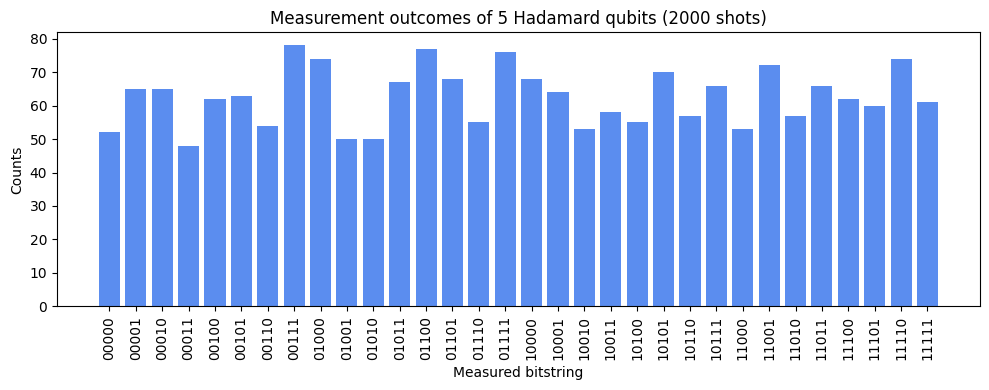

Expected count per outcome under a perfectly uniform distribution: ~62.5
Deviations from this value are finite-sample statistical fluctuations, not bias.

Per-qubit estimate of P(measuring 1):
  qubit 0: 0.516
  qubit 1: 0.492
  qubit 2: 0.519
  qubit 3: 0.511
  qubit 4: 0.498


In [9]:
sorted_items = sorted(counts.items())
labels = [item[0] for item in sorted_items]
values = [item[1] for item in sorted_items]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(labels, values, color='#5b8def')
ax.set_xlabel('Measured bitstring')
ax.set_ylabel('Counts')
ax.set_title(f'Measurement outcomes of {demo_circuit.num_qubits} Hadamard qubits ({DISTRIBUTION_SHOTS} shots)')
ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

expected_count = DISTRIBUTION_SHOTS / len(counts) if counts else 0
print(f'Expected count per outcome under a perfectly uniform distribution: ~{expected_count:.1f}')
print('Deviations from this value are finite-sample statistical fluctuations, not bias.')

# Bonus: per-qubit marginal probability of measuring 1.
num_bits = demo_circuit.num_qubits
ones_per_bit = [0] * num_bits
total_shots = sum(counts.values())
for bitstring, count in counts.items():
    for position, character in enumerate(reversed(bitstring)):
        if character == '1':
            ones_per_bit[position] += count

print()
print('Per-qubit estimate of P(measuring 1):')
for position, ones in enumerate(ones_per_bit):
    print(f'  qubit {position}: {ones / total_shots:.3f}')

## From Bits to Music

Every note in the melody consumes exactly `BITS_PER_NOTE = 12` quantum-measured bits, split into five fixed-size groups:

| Bit range (within a 12-bit chunk) | Bits | Range | Musical parameter |
|---|---|---|---|
| 0-2   | 3 | 0-7 | Scale degree (with automatic octave wrap) |
| 3-4   | 2 | 0-3 | Octave offset |
| 5-6   | 2 | 0-3 | Note duration (index into a fixed list) |
| 7-9   | 3 | 0-7 | Velocity (loudness), scaled into VELOCITY_RANGE |
| 10-11 | 2 | 0-3 | Rest flag (rest if value equals REST_THRESHOLD_VALUE) |

This exact grouping is defined once, in the `BIT_ALLOCATION` dictionary (see the Configuration cell), and is reused everywhere in the notebook so the code and this table can never disagree.

The scale degree is converted to a note using a simple, elegant wrap-around rule: the semitone interval for the note is looked up from the configured scale using `degree % len(scale)`, and every full wrap adds one octave (`12 * (degree // len(scale))`). A 7-note major scale plus this wrap-around naturally reproduces the classic 0-7 -> C D E F G A B C' mapping, while also working correctly for shorter scales such as a pentatonic scale.

In [10]:
# Scale definitions: semitone offsets from the root, without repeating
# the octave note. The octave repeat is produced automatically by the
# wrap-around rule in quantum_bits_to_music_parameters (next section).
SCALES = {
    'major':            [0, 2, 4, 5, 7, 9, 11],
    'natural_minor':    [0, 2, 3, 5, 7, 8, 10],
    'pentatonic_major': [0, 2, 4, 7, 9],
    'pentatonic_minor': [0, 3, 5, 7, 10],
    'chromatic':        list(range(12)),
}

NOTE_NAME_TO_PITCH_CLASS = {
    'C': 0, 'C#': 1, 'Db': 1, 'D': 2, 'D#': 3, 'Eb': 3, 'E': 4, 'F': 5,
    'F#': 6, 'Gb': 6, 'G': 7, 'G#': 8, 'Ab': 8, 'A': 9, 'A#': 10, 'Bb': 10, 'B': 11,
}

NOTE_NAMES_SHARP = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']


def midi_to_note_name(midi_note: int) -> str:
    '''Convert a MIDI note number to a note-name/octave string, e.g. 60 -> C4.'''
    if not (0 <= midi_note <= 127):
        raise ValueError(f'MIDI note {midi_note} out of range [0, 127].')
    pitch_class = midi_note % 12
    octave = (midi_note // 12) - 1
    return f'{NOTE_NAMES_SHARP[pitch_class]}{octave}'


# Validate the configuration defined in the Configuration cell.
assert SCALE_NAME in SCALES, f'Unknown scale {SCALE_NAME}. Options: {list(SCALES.keys())}'
assert ROOT_NOTE in NOTE_NAME_TO_PITCH_CLASS, f'Unknown root note {ROOT_NOTE}.'
assert len(NOTE_DURATION_OPTIONS) > 0, 'NOTE_DURATION_OPTIONS must not be empty.'
assert VELOCITY_RANGE[0] < VELOCITY_RANGE[1], 'VELOCITY_RANGE must be (min, max) with min < max.'

print(f'Scale: {ROOT_NOTE} {SCALE_NAME} -> semitone intervals {SCALES[SCALE_NAME]}')

Scale: C major -> semitone intervals [0, 2, 4, 5, 7, 9, 11]


In [11]:
def generate_quantum_bits(num_bits: int, num_qubits: int = NUM_QUBITS):
    '''
    Generate a bitstream of exactly num_bits classical bits by repeatedly
    executing the Hadamard superposition circuit on a quantum simulator
    and recording every individual measurement shot.

    Each shot is an independent execution of: |0>^n -> H^n -> measure.
    memory=True instructs the simulator to report the outcome of every
    individual shot rather than just aggregated counts, which is what
    allows building a sequence of quantum measurement outcomes.

    Parameters
    ----------
    num_bits : int
        Minimum number of bits required.
    num_qubits : int
        Number of qubits used per circuit execution (per shot).

    Returns
    -------
    bitstream : str
        A string of 0/1 characters of length exactly num_bits.
    metadata : dict
        Information about how the bits were produced, for transparency.
    '''
    if num_bits < 1:
        raise ValueError('num_bits must be a positive integer.')
    if num_qubits < 1:
        raise ValueError('num_qubits must be a positive integer.')
    if 'simulator' not in globals():
        raise RuntimeError(
            'The AerSimulator has not been initialized yet. Run the '
            'Run Quantum Experiment cell above before generating a melody.'
        )

    shots_needed = -(-num_bits // num_qubits)  # ceiling division
    circuit = build_hadamard_circuit(num_qubits)
    compiled_circuit = transpile(circuit, simulator)

    try:
        job = simulator.run(compiled_circuit, shots=shots_needed, memory=True)
        result = job.result()
        shot_outcomes = result.get_memory()  # one bitstring per shot, in order
    except Exception as exc:
        raise RuntimeError(
            'Quantum bit generation failed. The randomness source for this '
            'experiment must come from quantum circuit measurement; no '
            'classical fallback is used. Original error: ' + str(exc)
        ) from exc

    bitstream = ''.join(shot_outcomes)[:num_bits]

    metadata = {
        'num_qubits_per_shot': num_qubits,
        'shots_executed': shots_needed,
        'bits_requested': num_bits,
        'bits_produced_before_trim': len(shot_outcomes) * num_qubits,
        'backend': SIMULATOR_BACKEND,
    }
    return bitstream, metadata


# Self-check: request a small sample and inspect it.
sample_bits, sample_metadata = generate_quantum_bits(32)
print('Sample quantum-derived bitstream (32 bits):')
print(sample_bits)
print()
print('Generation metadata:')
for key, value in sample_metadata.items():
    print(f'  {key}: {value}')

Sample quantum-derived bitstream (32 bits):
00010110011000100000011111000101

Generation metadata:
  num_qubits_per_shot: 8
  shots_executed: 4
  bits_requested: 32
  bits_produced_before_trim: 32
  backend: aer_simulator


In [12]:
def bits_to_int(bits: str) -> int:
    '''
    Convert a string of 0/1 characters into its unsigned integer value,
    using standard binary place value with the most significant bit first.

    Example: 000 -> 0, 001 -> 1, 010 -> 2, ..., 111 -> 7.
    '''
    if not isinstance(bits, str) or len(bits) == 0:
        raise ValueError('bits must be a non-empty string.')
    if any(character not in '01' for character in bits):
        raise ValueError(f'bits must only contain 0/1 characters, got: {bits!r}')
    return int(bits, 2)


# Demonstration.
for example in ['000', '001', '010', '011', '100', '101', '110', '111']:
    print(f'{example} -> {bits_to_int(example)}')

000 -> 0
001 -> 1
010 -> 2
011 -> 3
100 -> 4
101 -> 5
110 -> 6
111 -> 7


In [13]:
def quantum_bits_to_music_parameters(note_bits: str) -> dict:
    '''
    Map a chunk of quantum-derived bits (length BITS_PER_NOTE) to a
    dictionary of musical parameters, using only the deterministic
    configuration defined earlier (SCALES, OCTAVE_BASE, and so on).

    No random / numpy.random is used here. All stochastic behaviour
    originates from the bits produced by the quantum circuit (or, in the
    clearly separated comparison section, from a classical generator that
    is passed through this same function on purpose, for a fair comparison).
    '''
    if len(note_bits) != BITS_PER_NOTE:
        raise ValueError(f'Expected {BITS_PER_NOTE} bits, got {len(note_bits)}.')

    cursor = 0
    bit_slices = {}
    for name, length in BIT_ALLOCATION.items():
        bit_slices[name] = note_bits[cursor:cursor + length]
        cursor += length

    scale_degree_raw = bits_to_int(bit_slices['scale_degree'])  # 0-7
    octave_raw = bits_to_int(bit_slices['octave'])              # 0-3
    duration_raw = bits_to_int(bit_slices['duration'])          # 0-3
    velocity_raw = bits_to_int(bit_slices['velocity'])          # 0-7
    rest_raw = bits_to_int(bit_slices['rest'])                  # 0-3

    scale_intervals = SCALES[SCALE_NAME]
    degree_index = scale_degree_raw % len(scale_intervals)
    degree_octave_offset = scale_degree_raw // len(scale_intervals)
    semitone_interval = scale_intervals[degree_index] + 12 * degree_octave_offset

    octave = OCTAVE_BASE + (octave_raw % OCTAVE_SPAN)
    root_pitch_class = NOTE_NAME_TO_PITCH_CLASS[ROOT_NOTE]
    total_semitones = root_pitch_class + semitone_interval
    midi_note = 12 * (octave + 1) + total_semitones
    midi_note = max(0, min(127, midi_note))

    duration = NOTE_DURATION_OPTIONS[duration_raw % len(NOTE_DURATION_OPTIONS)]

    velocity_min, velocity_max = VELOCITY_RANGE
    max_velocity_raw = (2 ** BIT_ALLOCATION['velocity']) - 1
    velocity = round(velocity_min + (velocity_raw / max_velocity_raw) * (velocity_max - velocity_min))

    is_rest = (rest_raw == REST_THRESHOLD_VALUE)

    return {
        'bits': note_bits,
        'scale_degree_raw': scale_degree_raw,
        'octave_raw': octave_raw,
        'duration_raw': duration_raw,
        'velocity_raw': velocity_raw,
        'rest_raw': rest_raw,
        'midi_note': midi_note,
        'note_name': '-' if is_rest else midi_to_note_name(midi_note),
        'octave': octave,
        'duration': duration,
        'velocity': velocity,
        'is_rest': is_rest,
    }


# Demonstration with a hand-written all-zero bit chunk.
example_parameters = quantum_bits_to_music_parameters('0' * BITS_PER_NOTE)
example_parameters

{'bits': '000000000000',
 'scale_degree_raw': 0,
 'octave_raw': 0,
 'duration_raw': 0,
 'velocity_raw': 0,
 'rest_raw': 0,
 'midi_note': 60,
 'note_name': 'C4',
 'octave': 4,
 'duration': 0.25,
 'velocity': 55,
 'is_rest': False}

In [14]:
def generate_quantum_melody(num_notes: int = NUM_NOTES) -> pd.DataFrame:
    '''
    Generate a full melody driven end-to-end by quantum measurement outcomes.

    Steps:
      1. Request num_notes * BITS_PER_NOTE bits from the quantum circuit.
      2. Split the bitstream into one chunk per note.
      3. Map each chunk to musical parameters.
      4. Return the result as a pandas DataFrame, one row per note.
    '''
    if num_notes < 1:
        raise ValueError('num_notes must be a positive integer.')

    total_bits_needed = num_notes * BITS_PER_NOTE
    bitstream, generation_metadata = generate_quantum_bits(total_bits_needed)

    rows = []
    for note_index in range(num_notes):
        start = note_index * BITS_PER_NOTE
        end = start + BITS_PER_NOTE
        note_bits = bitstream[start:end]
        parameters = quantum_bits_to_music_parameters(note_bits)
        rows.append({
            'index': note_index,
            'bits': note_bits,
            'note_name': parameters['note_name'],
            'midi_note': parameters['midi_note'],
            'octave': parameters['octave'],
            'duration_beats': parameters['duration'],
            'velocity': parameters['velocity'],
            'is_rest': parameters['is_rest'],
        })

    melody_dataframe = pd.DataFrame(rows)
    melody_dataframe.attrs['generation_metadata'] = generation_metadata
    melody_dataframe.attrs['full_bitstream'] = bitstream
    return melody_dataframe


quantum_melody = generate_quantum_melody(NUM_NOTES)
bitstream_length = len(quantum_melody.attrs['full_bitstream'])
print(f'Generated {len(quantum_melody)} notes from {bitstream_length} quantum-measured bits.')

Generated 24 notes from 288 quantum-measured bits.


In [15]:
def format_melody_table(melody_dataframe: pd.DataFrame, bits_label: str = 'Quantum Bits') -> pd.DataFrame:
    '''Return a human-readable copy of a melody DataFrame for display.'''
    display_dataframe = melody_dataframe.copy()
    display_dataframe['note_name'] = display_dataframe.apply(
        lambda row: 'REST' if row['is_rest'] else row['note_name'], axis=1
    )
    display_dataframe = display_dataframe[[
        'index', 'bits', 'note_name', 'octave', 'duration_beats', 'velocity', 'is_rest'
    ]]
    display_dataframe.columns = ['#', bits_label, 'Note', 'Octave', 'Duration (beats)', 'Velocity', 'Rest?']
    return display_dataframe


format_melody_table(quantum_melody)

,#,Quantum Bits,Note,Octave,Duration (beats),Velocity,Rest?
0,0,110011000010,B5,5,0.75,55,False
1,1,110001111011,REST,4,1.00,102,True
2,2,001110001011,REST,5,0.25,71,True
3,3,010010111010,E5,5,0.50,102,False
4,4,101001000000,A4,4,0.75,55,False
5,5,101100100010,A4,4,0.50,55,False
6,6,100110011001,G5,5,0.25,102,False
7,7,100011000110,G5,5,0.75,63,False
8,8,110001110011,REST,4,1.00,86,True
9,9,111111110001,C6,5,1.00,86,False


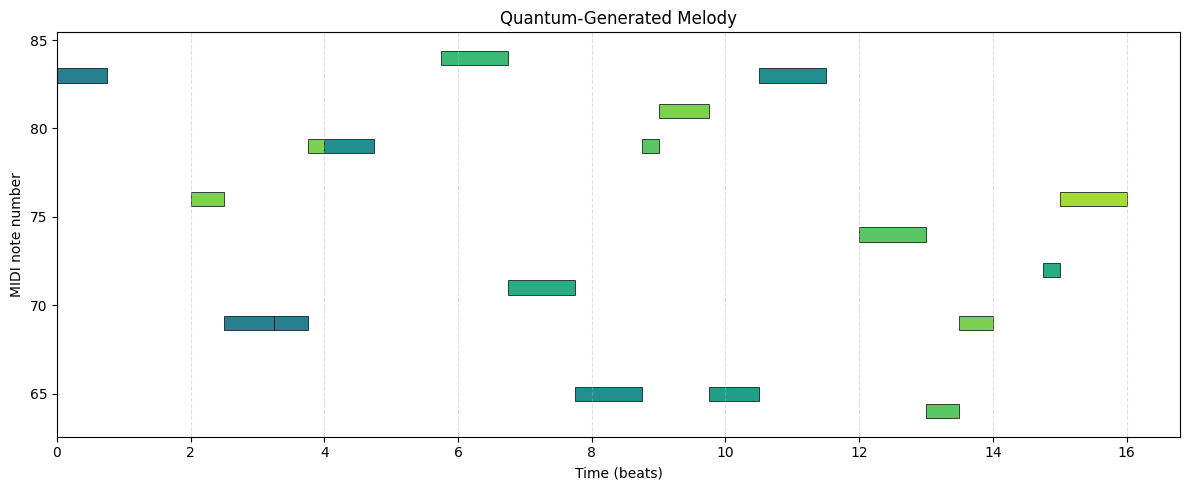

In [16]:
def plot_piano_roll(melody_dataframe: pd.DataFrame, title: str = 'Quantum-Generated Melody') -> None:
    '''
    Draw a simple piano-roll style plot: horizontal bars for pitched notes
    over time (in beats), with color related to velocity. Rests appear as
    gaps in the timeline.
    '''
    fig, ax = plt.subplots(figsize=(12, 5))
    time_cursor = 0.0
    for _, row in melody_dataframe.iterrows():
        duration = row['duration_beats']
        if not row['is_rest']:
            ax.barh(
                y=row['midi_note'],
                width=duration,
                left=time_cursor,
                height=0.8,
                color=plt.cm.viridis(row['velocity'] / 127),
                edgecolor='black',
                linewidth=0.5,
            )
        time_cursor += duration

    ax.set_xlabel('Time (beats)')
    ax.set_ylabel('MIDI note number')
    ax.set_title(title)
    ax.grid(True, axis='x', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()


plot_piano_roll(quantum_melody)

In [17]:
OUTPUT_DIR = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)


def melody_to_midi_file(melody_dataframe: pd.DataFrame, filename: str, tempo: int = TEMPO) -> str:
    '''
    Render a melody DataFrame (as produced by generate_quantum_melody) into
    a standard MIDI file. Returns the full path to the written file.
    '''
    midi_file = MIDIFile(1)  # one track
    track, channel = 0, 0
    midi_file.addTempo(track, time=0, tempo=tempo)

    time_cursor = 0.0
    for _, row in melody_dataframe.iterrows():
        duration = row['duration_beats']
        if not row['is_rest']:
            midi_file.addNote(
                track=track,
                channel=channel,
                pitch=int(row['midi_note']),
                time=time_cursor,
                duration=duration,
                volume=int(row['velocity']),
            )
        time_cursor += duration

    filepath = os.path.join(OUTPUT_DIR, filename)
    with open(filepath, 'wb') as output_file:
        midi_file.writeFile(output_file)
    return filepath


quantum_midi_path = melody_to_midi_file(quantum_melody, 'quantum_randomness_melody.mid')
print(f'MIDI file written to: {quantum_midi_path}')

MIDI file written to: outputs/quantum_randomness_melody.mid


In [18]:
SOUNDFONT_CANDIDATES = [
    '/usr/share/sounds/sf2/FluidR3_GM.sf2',
    '/usr/share/sounds/sf2/TimGM6mb.sf2',
]


def render_midi_to_wav(midi_path: str) -> str:
    '''
    Attempt to render a MIDI file to WAV using the FluidSynth command-line
    tool and a General MIDI soundfont, so it can be played inline in Colab.
    Returns the WAV path on success, or raises RuntimeError with a clear
    explanation if rendering is not possible in the current environment.
    '''
    if shutil.which('fluidsynth') is None:
        raise RuntimeError(
            'FluidSynth is not installed. Run the installation cell '
            '(it installs fluidsynth and a General MIDI soundfont).'
        )
    soundfont = next((sf for sf in SOUNDFONT_CANDIDATES if os.path.exists(sf)), None)
    if soundfont is None:
        raise RuntimeError(
            'No General MIDI soundfont found. Run the installation cell '
            '(it installs fluid-soundfont-gm).'
        )
    wav_path = midi_path.replace('.mid', '.wav')
    result = subprocess.run(
        ['fluidsynth', '-ni', soundfont, midi_path, '-F', wav_path, '-r', '44100'],
        capture_output=True, text=True,
    )
    if result.returncode != 0 or not os.path.exists(wav_path):
        raise RuntimeError(f'FluidSynth rendering failed: {result.stderr}')
    return wav_path


try:
    quantum_wav_path = render_midi_to_wav(quantum_midi_path)
    print(f'Rendered audio: {quantum_wav_path}')
    display(Audio(quantum_wav_path))
except RuntimeError as exc:
    print('Audio rendering was not possible in this environment:')
    print(f'  {exc}')
    print(f'The MIDI file itself was still created successfully: {quantum_midi_path}')
    print('Download it and play it with any MIDI-capable player or DAW.')

Rendered audio: outputs/quantum_randomness_melody.wav


## Listen to the Result

The melody rendered above was generated from the measurement outcomes of a quantum circuit executed on the Qiskit Aer **simulator**. Concretely:

> The pitch, octave, duration, velocity, and rest pattern of every note were determined by classical bits extracted from measuring qubits that had been placed into superposition by Hadamard gates.

Two important qualifications:

1. The randomness source is a **simulator**, not physical quantum hardware. See "Simulator vs Real Quantum Hardware" below.
2. The audio/MIDI rendering itself is an ordinary classical process (music theory, MIDI encoding, audio synthesis). Only the input numbers to that process are quantum-derived.

In [19]:
MELODIES_TO_GENERATE = 5  # Each melody uses a fresh, independent set of quantum measurements.

quantum_melodies = []
for melody_number in range(1, MELODIES_TO_GENERATE + 1):
    melody = generate_quantum_melody(NUM_NOTES)
    quantum_melodies.append(melody)
    rest_count = int(melody['is_rest'].sum())
    generated_bitstream_length = len(melody.attrs['full_bitstream'])
    print(f'Melody {melody_number}/{MELODIES_TO_GENERATE}: {len(melody)} notes, {rest_count} rests, bitstream length {generated_bitstream_length}.')

Melody 1/5: 24 notes, 4 rests, bitstream length 288.
Melody 2/5: 24 notes, 5 rests, bitstream length 288.
Melody 3/5: 24 notes, 4 rests, bitstream length 288.
Melody 4/5: 24 notes, 10 rests, bitstream length 288.
Melody 5/5: 24 notes, 3 rests, bitstream length 288.


In [20]:
saved_paths = []
for melody_number, melody in enumerate(quantum_melodies, start=1):
    filename = f'quantum_melody_{melody_number:02d}.mid'
    path = melody_to_midi_file(melody, filename)
    saved_paths.append(path)
    print(f'Saved: {path}')

Saved: outputs/quantum_melody_01.mid
Saved: outputs/quantum_melody_02.mid
Saved: outputs/quantum_melody_03.mid
Saved: outputs/quantum_melody_04.mid
Saved: outputs/quantum_melody_05.mid
